# 00_raw_eda · 091170 KODEX 은행 (slot 7) — ETF Raw EDA

SSOT: `notebooks/_template/00_etf_raw_eda.ipynb` → `scripts/build_notebooks.py` 로 생성. 이 파일을 직접 고치지 말 것.

In [1]:
TICKER = "091170"
SLOT = 7

In [2]:
import sys, os, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown
warnings.filterwarnings("ignore")
np.random.seed(0)

ROOT = Path.cwd().resolve()
while not (ROOT / "config" / "universe.csv").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("config/universe.csv not found")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src import eda_utils as eu
from src.style import setup_notebook, banner, kpis
setup_notebook()
LIMITATIONS = [eu.LIMITATION_PRICE]
def cap(sec, st, extra=None):
    display(Markdown(eu.caption(sec, st, extra)))

## 00 Identity / Domain Card

In [3]:
U = eu.read_universe(ROOT)
row = U.loc[U["ticker"] == TICKER].iloc[0].to_dict()
banner(f"{TICKER} · {row.get('name','')}", f"UNIVERSE_STATUS={row.get('universe_status','PROVISIONAL') or 'PROVISIONAL'} — 공식 list 입수 시 교체")
display(pd.DataFrame([row]).T.rename(columns={0: "value"}))
KEYF = ["benchmark", "benchmark_proxy_ticker", "currency_hedge", "replication", "trading_hours_note", "structural_notes", "confidence"]
display(pd.DataFrame({"field": KEYF, "value": [row.get(k, "(missing column)") for k in KEYF]}))
print("price policy:", eu.PRICE_POLICY_UNADJ)

,value
slot,7
ticker,091170
name,KODEX 은행
provider_brand,KODEX (삼성자산운용)
listing_date,2006-06
listing_date_source,domain knowledge [ANA]; FDR first row 2014-07-...
data_start,2019-01-02
asset_scope,domestic_equity
category,sector
benchmark,KRX 은행 (추정)


,field,value
0,benchmark,KRX 은행 (추정)
1,benchmark_proxy_ticker,069500
2,currency_hedge,n/a (KRW)
3,replication,physical
4,trading_hours_note,KRX same-session
5,structural_notes,[OBS] Category=2. 금리·배당 민감 가치주 섹터 [ANA]; 고배당 E...
6,confidence,low


price policy: FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으로 추정(069500/KS200 누적비 1.155 ≈ TR 1.163), O/H/L 조정 일관성 미보장 — KNOWN_LIMITATION


## 01 Raw Data Audit

In [4]:
raw, PROV = eu.load_raw(eu.raw_path(TICKER))
print("price_policy:", PROV["price_policy"])
display(pd.DataFrame([{k: v for k, v in PROV.items() if k != "duplicate_dates"}]).T.rename(columns={0: "value"}))
display(eu.quality_summary(raw))
OHLC_BAD = eu.ohlc_violations(raw); GAPS = eu.date_gaps(raw, 5)
print("OHLC violations:", len(OHLC_BAD)); display(OHLC_BAD.head(10))
print("date gaps > 5 calendar days:", len(GAPS)); display(GAPS)
x, FLAGS = eu.engineer_basic(raw)
HAS_VOL = FLAGS["has_volume"]
if not HAS_VOL: LIMITATIONS.append("no_volume")
if FLAGS["n_zero_volume_days"] > 0: LIMITATIONS.append("zero_volume_days")
if len(x) < 500: LIMITATIONS.append("short_history")
if PROV["n_duplicate_dates"] > 0: LIMITATIONS.append("duplicate_dates")
START, END, N = x["date"].iloc[0], x["date"].iloc[-1], len(x)
ZERO_VOL_RATIO = FLAGS["n_zero_volume_days"] / N
print("first", START.date(), "last", END.date())

price_policy: FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으로 추정(069500/KS200 누적비 1.155 ≈ TR 1.163), O/H/L 조정 일관성 미보장 — KNOWN_LIMITATION


,value
source_file,/home/sieg/projects-wsl/hongik_univ_26_2/SA/ET...
rows_raw,1903
n_unparseable_dates,0
was_sorted,True
n_duplicate_dates,0
rows_after,1903
price_policy,FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으...
has_adj_close,False
has_volume,True
n_zero_volume_days,0


,column,dtype,n,missing_n,missing_pct,unique_n
0,date,datetime64[us],1903,0,0.0000,1903
1,open,int64,1903,0,0.0000,1313
2,high,int64,1903,0,0.0000,1292
3,low,int64,1903,0,0.0000,1301
4,close,int64,1903,0,0.0000,1312
5,volume,int64,1903,0,0.0000,1902
6,change,float64,1903,0,0.0000,1853
7,price,int64,1903,0,0.0000,1312


OHLC violations: 0


,date,open,high,low,close


date gaps > 5 calendar days: 9


,date,prev_date,gap_days
0,2019-02-07,2019-02-01,6
1,2020-10-05,2020-09-29,6
2,2021-09-23,2021-09-17,6
3,2022-02-03,2022-01-28,6
4,2023-10-04,2023-09-27,7
5,2024-09-19,2024-09-13,6
6,2025-01-31,2025-01-24,7
7,2025-10-10,2025-10-02,8
8,2026-02-19,2026-02-13,6


first 2019-01-02 last 2026-10-02


In [5]:
extra = [f"가격 정책: {PROV['price_policy']}"]
if not HAS_VOL: extra.append("거래량 컬럼이 없거나 전부 0 → 거래량 기반 분석 생략")
cap("01", {"rows_raw": PROV["rows_raw"], "rows_after": PROV["rows_after"], "n_duplicate_dates": PROV["n_duplicate_dates"],
           "n_unparseable_dates": PROV["n_unparseable_dates"], "was_sorted": PROV["was_sorted"], "ohlc_violations": len(OHLC_BAD),
           "n_gaps_gt5d": len(GAPS), "n_zero_volume_days": FLAGS["n_zero_volume_days"], "zero_vol_ratio": ZERO_VOL_RATIO,
           "first": START.date(), "last": END.date()}, extra)

#### 01 · WHAT WE SEE
- `rows_raw` = 1903
- `rows_after` = 1903
- `n_duplicate_dates` = 0
- `n_unparseable_dates` = 0
- `was_sorted` = True
- `ohlc_violations` = 0
- `n_gaps_gt5d` = 9
- `n_zero_volume_days` = 0
- `zero_vol_ratio` = 0
- `first` = 2019-01-02
- `last` = 2026-10-02

#### WHY IT MATTERS
행 수·중복·결측·날짜 공백은 이후 모든 rolling 창과 정렬(merge)의 기준이 된다. 감사되지 않은 행은 전처리 단계에서 조용히 왜곡을 만든다.

#### WHAT WE DO NOT KNOW
- 원천(FDR) 이 휴장일 외의 누락을 어떻게 처리하는지는 이 데이터만으로 확인할 수 없다.
- 가격 정책: FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으로 추정(069500/KS200 누적비 1.155 ≈ TR 1.163), O/H/L 조정 일관성 미보장 — KNOWN_LIMITATION

#### NEXT QUESTION
- 감사에서 걸린 행(중복/공백/OHLC 위반)을 전처리에서 제거·보간·flag 중 무엇으로 처리할 것인가?

> A/C 해석 통합 대기 (ETF_CARDS)


## 02 Whole-History Visual Scan

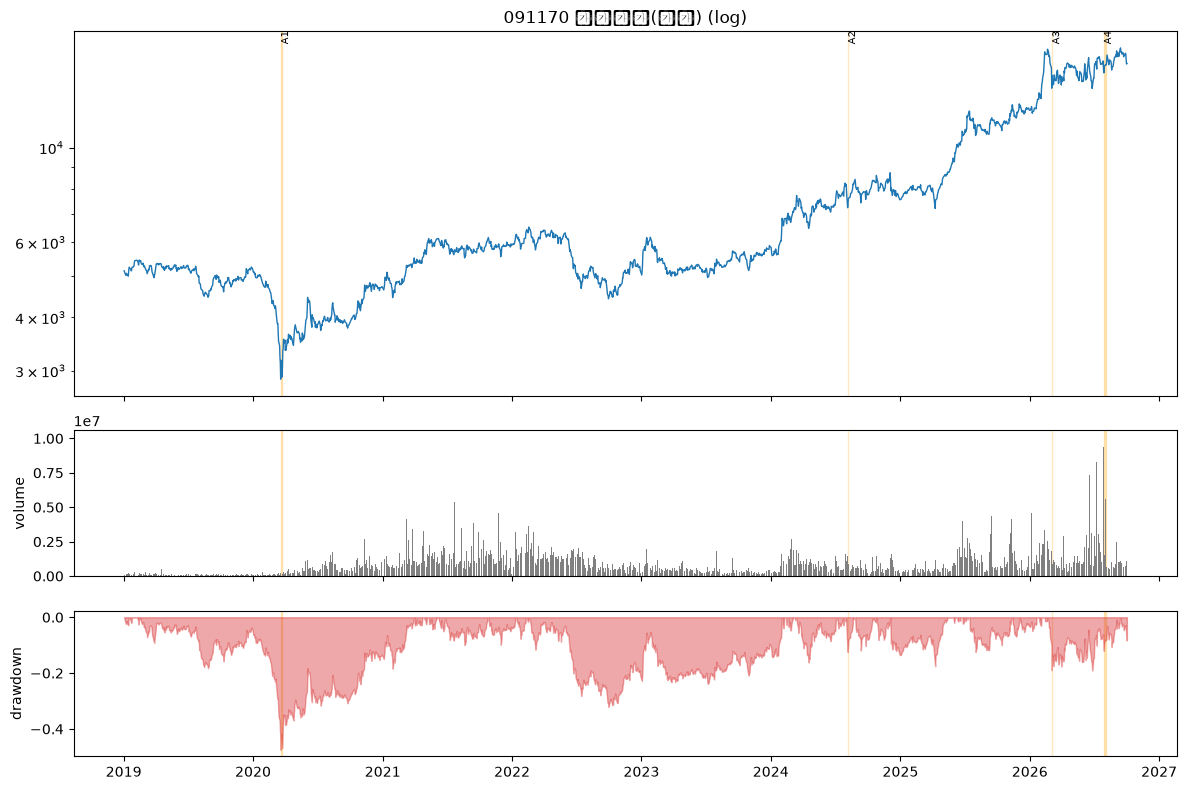

In [6]:
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True, height_ratios=[3, 1.2, 1.2])
ax[0].plot(x["date"], x["price"], lw=1); ax[0].set_yscale("log"); ax[0].set_title(f"{TICKER} 조정가격(추정) (log)")
ANCH = eu.read_event_anchors(ROOT)
for _, a in ANCH.iterrows():
    s0, s1 = pd.to_datetime(a["start"], errors="coerce"), pd.to_datetime(a["end"] or a["start"], errors="coerce")
    if pd.notna(s0):
        for axx in ax: axx.axvspan(s0, s1 if pd.notna(s1) else s0, color="orange", alpha=.25)
        ax[0].text(s0, ax[0].get_ylim()[1], a.get("anchor_id", ""), fontsize=7, va="top", rotation=90)
if HAS_VOL: ax[1].bar(x["date"], x["volume"], width=1.5, color="gray")
else: ax[1].text(0.5, 0.5, "no volume", transform=ax[1].transAxes, ha="center")
ax[1].set_ylabel("volume")
ax[2].fill_between(x["date"], x["drawdown"], 0, color="tab:red", alpha=.4); ax[2].set_ylabel("drawdown")
plt.tight_layout(); plt.show()

In [7]:
cap("02", {"price_first": x["price"].iloc[0], "price_last": x["price"].iloc[-1],
           "price_min": x["price"].min(), "price_max": x["price"].max(), "min_drawdown": x["drawdown"].min(),
           "volume_median": x["volume"].median() if HAS_VOL else "n/a"})

#### 02 · WHAT WE SEE
- `price_first` = 5142
- `price_last` = 15755
- `price_min` = 2866
- `price_max` = 17128
- `min_drawdown` = -0.4744
- `volume_median` = 5.697e+05

#### WHY IT MATTERS
전체 이력의 수준·거래량·낙폭을 한 화면에서 보면 구조 변화(regime)나 이상 구간이 있는지, 정규화 창을 어디서 끊어야 할지 판단할 근거가 된다.

#### WHAT WE DO NOT KNOW
- 가격 점프가 분배금/분할 때문인지 실제 가격 변동인지 이 데이터만으로 구분할 수 없다.

#### NEXT QUESTION
- 전체 기간을 하나의 정규화 창으로 볼 수 있는가, 아니면 구간을 나눠야 하는가?

> A/C 해석 통합 대기 (ETF_CARDS)


## 03 Return Distribution

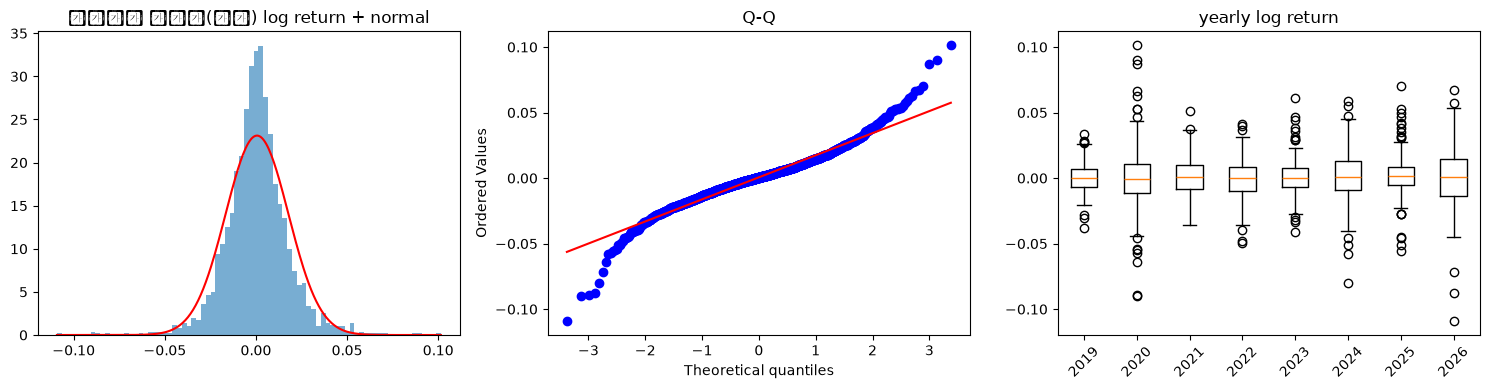

In [8]:
r = x["log_ret"].dropna()
K = {"mean": r.mean(), "std": r.std(), "ann_vol": r.std() * np.sqrt(252), "skew": stats.skew(r),
     "ex_kurt": stats.kurtosis(r), "ex_kurt_trim3": eu.kurt_trim(r, 3), "p01": r.quantile(.01), "p99": r.quantile(.99), "n": len(r)}
kpis([(k, f"{v:.4g}") for k, v in K.items()])
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(r, bins=80, density=True, alpha=.6); g = np.linspace(r.min(), r.max(), 300)
ax[0].plot(g, stats.norm.pdf(g, r.mean(), r.std()), "r-"); ax[0].set_title("조정가격 수익률(추정) log return + normal")
stats.probplot(r, dist="norm", plot=ax[1]); ax[1].set_title("Q-Q")
yr = x.dropna(subset=["log_ret"]).groupby(x["date"].dt.year)["log_ret"]
ax[2].boxplot([v.values for _, v in yr], tick_labels=[str(k) for k, _ in yr]); ax[2].set_title("yearly log return")
ax[2].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

In [9]:
cap("03", K)

#### 03 · WHAT WE SEE
- `mean` = 0.0005887
- `std` = 0.01725
- `ann_vol` = 0.2738
- `skew` = -0.01327
- `ex_kurt` = 4.313
- `ex_kurt_trim3` = 3.075
- `p01` = -0.04515
- `p99` = 0.04959
- `n` = 1902

#### WHY IT MATTERS
수익률 분포의 꼬리(첨도·왜도·분위수)는 z-score 같은 정규 가정 기반 정규화가 얼마나 맞지 않는지를 직접 보여준다.

#### WHAT WE DO NOT KNOW
- 분포 모양이 기간에 따라 안정적인지는 단일 전체표본 통계로는 알 수 없다.

#### NEXT QUESTION
- 꼬리 두께를 감안할 때 z-score 대신 robust/분위수 기반 정규화가 필요한가?

> A/C 해석 통합 대기 (ETF_CARDS)


### 03b Core stats — full / by year / 2026-07-20~08-10 제외 / DQ 포함 vs 제외

In [10]:
SV, DQ_NOTE = eu.stats_variants(x, ROOT, TICKER)
display(SV); print("DQ:", DQ_NOTE)
if DQ_NOTE != "no_dq_flags": LIMITATIONS.append("dq_flagged_dates")  # 해당일 포함/제외 병기됨
exk = [i for i in SV.index if i.startswith("excl_")][0]
cap("03", {"full_ann_vol": SV.loc["full", "ann_vol"], "excl_window_ann_vol": SV.loc[exk, "ann_vol"],
           "full_ex_kurt": SV.loc["full", "ex_kurt"], "excl_window_ex_kurt": SV.loc[exk, "ex_kurt"],
           "dq_excluded_ex_kurt": SV.loc["dq_excluded", "ex_kurt"], "dq_note": DQ_NOTE,
           "year_ann_vol_min": SV.filter(like="year_", axis=0)["ann_vol"].min(), "year_ann_vol_max": SV.filter(like="year_", axis=0)["ann_vol"].max()})

,n,ann_vol,ex_kurt,ex_kurt_trim3,p01,p99,max_dd
full,"1,902.0000",0.2738,4.3128,3.0754,-0.0451,0.0496,-0.4744
year_2019,245.0000,0.1708,0.6933,0.0610,-0.0250,0.0271,-0.1823
year_2020,248.0000,0.3747,3.8017,2.5923,-0.0607,0.0777,-0.4406
year_2021,248.0000,0.2178,0.5005,-0.0586,-0.0307,0.0366,-0.1280
year_2022,246.0000,0.2427,0.3928,-0.0643,-0.0378,0.0342,-0.3208
year_2023,245.0000,0.2138,2.3070,0.7372,-0.0311,0.0416,-0.1957
year_2024,244.0000,0.2993,1.5975,0.3460,-0.0485,0.0463,-0.1622
year_2025,242.0000,0.2434,3.5113,2.2653,-0.0453,0.0484,-0.1237
year_2026,184.0000,0.3843,2.7192,0.0642,-0.0746,0.0544,-0.1909
excl_2026-07-20~2026-08-10,"1,886.0000",0.2731,4.3868,3.1296,-0.0452,0.0498,-0.4744


DQ: no_dq_flags


#### 03 · WHAT WE SEE
- `full_ann_vol` = 0.2738
- `excl_window_ann_vol` = 0.2731
- `full_ex_kurt` = 4.313
- `excl_window_ex_kurt` = 4.387
- `dq_excluded_ex_kurt` = 4.313
- `dq_note` = no_dq_flags
- `year_ann_vol_min` = 0.1708
- `year_ann_vol_max` = 0.3843

#### WHY IT MATTERS
수익률 분포의 꼬리(첨도·왜도·분위수)는 z-score 같은 정규 가정 기반 정규화가 얼마나 맞지 않는지를 직접 보여준다.

#### WHAT WE DO NOT KNOW
- 분포 모양이 기간에 따라 안정적인지는 단일 전체표본 통계로는 알 수 없다.

#### NEXT QUESTION
- 꼬리 두께를 감안할 때 z-score 대신 robust/분위수 기반 정규화가 필요한가?

> A/C 해석 통합 대기 (ETF_CARDS)


## 04 Volatility Dynamics

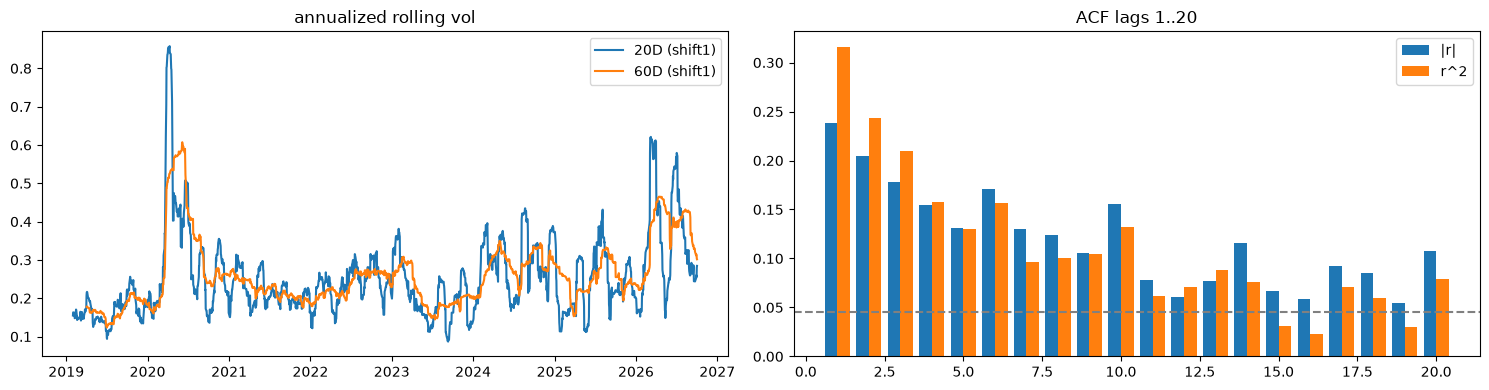

,lag,acf_absret,acf_sqret
0,1,0.2383,0.3161
1,2,0.2042,0.2432
2,3,0.1780,0.2098
3,4,0.1546,0.1577
4,5,0.1307,0.1306
5,6,0.1705,0.1562
6,7,0.1300,0.0963
7,8,0.1238,0.1010
8,9,0.1051,0.1040
9,10,0.1557,0.1317


,lb_stat,lb_pvalue
5,326.2900,0.0000
10,510.9188,0.0000
20,640.3842,0.0000


In [11]:
ACF_ABS = eu.acf(x["abs_ret"], 20); ACF_SQ = eu.acf(x["log_ret"] ** 2, 20)
VOL_OF_VOL = float((x["roll_vol_20"] / x["roll_vol_20"].mean()).std())
from statsmodels.stats.diagnostic import acorr_ljungbox
LB = acorr_ljungbox(x["abs_ret"].dropna(), lags=[5, 10, 20])
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(x["date"], x["roll_vol_20"] * np.sqrt(252), label="20D (shift1)")
ax[0].plot(x["date"], x["roll_vol_60"] * np.sqrt(252), label="60D (shift1)"); ax[0].legend(); ax[0].set_title("annualized rolling vol")
lags = np.arange(1, 21)
ax[1].bar(lags - .2, ACF_ABS, .4, label="|r|"); ax[1].bar(lags + .2, ACF_SQ, .4, label="r^2")
ax[1].axhline(1.96 / np.sqrt(len(x)), ls="--", c="gray"); ax[1].legend(); ax[1].set_title("ACF lags 1..20")
plt.tight_layout(); plt.show()
display(pd.DataFrame({"lag": lags, "acf_absret": ACF_ABS, "acf_sqret": ACF_SQ}).head(10)); display(LB)

In [12]:
cap("04", {"acf_absret_lag1": ACF_ABS[0], "acf_absret_lag5": ACF_ABS[4], "acf_sqret_lag1": ACF_SQ[0],
           "vol_of_vol(cv of roll_vol_20)": VOL_OF_VOL, "ljungbox_absret_lag20_p": LB["lb_pvalue"].iloc[-1],
           "roll_vol_20_ann_median": x["roll_vol_20"].median() * np.sqrt(252)})

#### 04 · WHAT WE SEE
- `acf_absret_lag1` = 0.2383
- `acf_absret_lag5` = 0.1307
- `acf_sqret_lag1` = 0.3161
- `vol_of_vol(cv of roll_vol_20)` = 0.4326
- `ljungbox_absret_lag20_p` = 8.783e-123
- `roll_vol_20_ann_median` = 0.2264

#### WHY IT MATTERS
변동성 군집(|r|, r^2 의 자기상관)이 있으면 고정 임계값보다 시간가변 baseline 정규화가 필요하다는 근거가 된다.

#### WHAT WE DO NOT KNOW
- 표본이 크면 Ljung-Box 는 작은 자기상관도 유의하게 만든다 — 유의성은 크기의 증거가 아니다.

#### NEXT QUESTION
- baseline 창 길이(20 vs 60)를 무엇으로 고를 것인가?

> A/C 해석 통합 대기 (ETF_CARDS)


## 05 Trading Activity

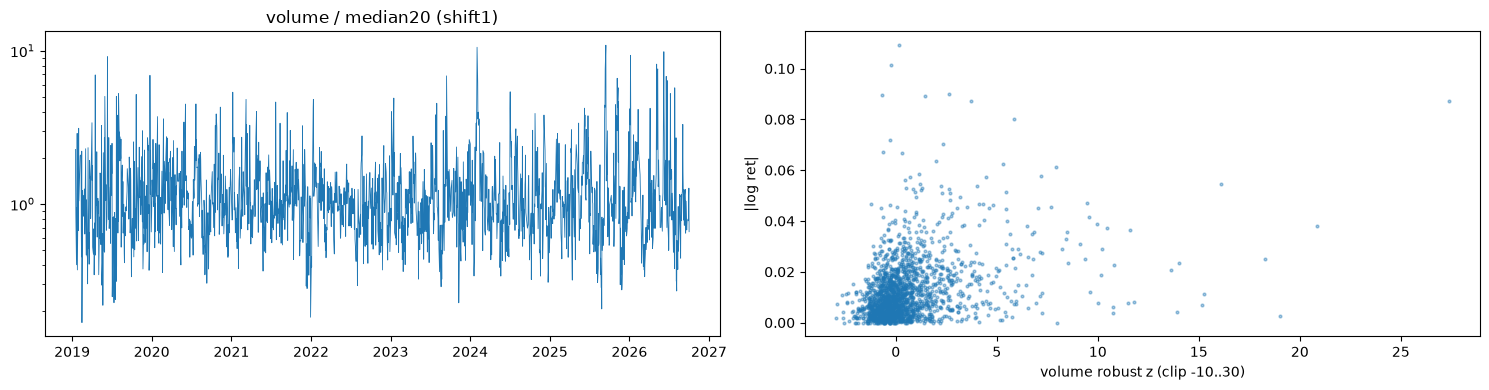

In [13]:
VOLST = {}
if HAS_VOL:
    vz = x["volume_robust_z_20"]
    rho, p = stats.spearmanr(x["abs_ret"], vz, nan_policy="omit")
    ext = x["abs_q95"].fillna(False)
    VOLST = {"spearman_absret_volz": rho, "spearman_p": p, "volz_median_extreme(abs_q95)": vz[ext].median(),
             "volz_median_normal": vz[~ext].median(), "volratio_median_extreme": x["volume_ratio_20"][ext].median(),
             "volratio_median_normal": x["volume_ratio_20"][~ext].median(), "n_mad_zero": FLAGS["n_mad_zero"]}
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    ax[0].plot(x["date"], x["volume_ratio_20"], lw=.6); ax[0].set_yscale("log"); ax[0].set_title("volume / median20 (shift1)")
    ax[1].scatter(vz.clip(-10, 30), x["abs_ret"], s=4, alpha=.4); ax[1].set_xlabel("volume robust z (clip -10..30)"); ax[1].set_ylabel("|log ret|")
    plt.tight_layout(); plt.show()
else:
    print("SKIP: 거래량 없음 (has_volume=False)")
    VOLST = {"skipped": "no_volume"}

In [14]:
cap("05", VOLST, None if HAS_VOL else ["거래량이 없어 이 절 분석을 생략했다."])

#### 05 · WHAT WE SEE
- `spearman_absret_volz` = 0.344
- `spearman_p` = 1.808e-53
- `volz_median_extreme(abs_q95)` = 2.174
- `volz_median_normal` = -0.03769
- `volratio_median_extreme` = 1.896
- `volratio_median_normal` = 0.9815
- `n_mad_zero` = 0

#### WHY IT MATTERS
거래량 baseline(shift(1))과 수익률 크기의 관계는 거래량을 극단 후보의 보조 신호로 쓸 수 있는지에 대한 근거가 된다.

#### WHAT WE DO NOT KNOW
- 거래량 급증의 원인(설정/환매, LP 호가, 리밸런싱)은 이 데이터에 없다.

#### NEXT QUESTION
- 거래량 robust z 를 극단 후보의 보조 조건으로 쓸 가치가 있는가?

> A/C 해석 통합 대기 (ETF_CARDS)


## 06 Drawdown / Recovery / Persistence

In [15]:
EP = eu.drawdown_episodes(x["price"], x["date"], 5)
i_min = int(x["drawdown"].idxmin()); MAX_DD = float(x["drawdown"].min()); MAX_DD_DATE = x["date"].iloc[i_min].date()
rec = x.index[(x.index > i_min) & (x["drawdown"] >= 0)]
RECOVERY_DAYS = int((x["date"].iloc[rec[0]] - x["date"].iloc[i_min]).days) if len(rec) else None
display(EP)
lp = np.log(x["price"])
fw = {}
for h in (1, 3, 5, 10):
    f = lp.shift(-h) - lp
    fw[h] = {"pos_q95": f[x["pos_q95"]].mean(), "neg_q05": f[x["neg_q05"]].mean(), "all": f.mean()}
FWD = pd.DataFrame(fw).T.rename_axis("h"); display(FWD)
print("※ EDA-only: 겹치는 표본, full-sample 분위수(look-ahead).")

,peak_date,trough_date,depth,recovery_date,recovery_days
0,2019-02-14,2020-03-19,-0.4744,2021-03-31,377.0000
1,2022-02-17,2022-09-30,-0.3208,2024-02-02,490.0000
2,2026-02-20,2026-06-26,-0.1909,2026-09-14,80.0000
3,2024-12-03,2025-04-09,-0.1752,2025-05-14,35.0000
4,2024-03-14,2024-04-17,-0.1622,2024-07-04,78.0000


,pos_q95,neg_q05,all
h,,,
1,0.0037,0.0013,0.0006
3,0.0081,0.0026,0.0018
5,0.0092,0.0049,0.0030
10,0.0089,0.0128,0.0062


※ EDA-only: 겹치는 표본, full-sample 분위수(look-ahead).


In [16]:
cap("06", {"max_dd": MAX_DD, "max_dd_date": MAX_DD_DATE, "recovery_days": RECOVERY_DAYS if RECOVERY_DAYS is not None else "not recovered",
           "fwd5_after_pos_q95": FWD.loc[5, "pos_q95"], "fwd5_after_neg_q05": FWD.loc[5, "neg_q05"], "fwd5_all": FWD.loc[5, "all"]})

#### 06 · WHAT WE SEE
- `max_dd` = -0.4744
- `max_dd_date` = 2020-03-19
- `recovery_days` = 377
- `fwd5_after_pos_q95` = 0.009189
- `fwd5_after_neg_q05` = 0.004922
- `fwd5_all` = 0.003042

#### WHY IT MATTERS
낙폭 깊이·회복 기간·극단일 이후 forward return 은 이벤트 창 길이와 사후 관측 구간 설계의 근거가 된다.

#### WHAT WE DO NOT KNOW
- forward return 은 겹치는 표본(overlapping)이라 독립 관측 수가 실제보다 적다. 인과가 아니다.

#### NEXT QUESTION
- 극단일 이후 며칠까지를 이벤트 창으로 볼 것인가?

> A/C 해석 통합 대기 (ETF_CARDS)


## 07 Candidate Extreme Windows

최종 label/threshold 아님. z 후보는 shift(1) baseline, q 후보는 full-sample(look-ahead).

,definition,n_days
0,pos_z2,82
1,neg_z2,58
2,abs_z2,140
3,pos_z2_5,41
4,neg_z2_5,31
5,abs_z2_5,72
6,pos_z3,24
7,neg_z3,17
8,abs_z3,41
9,pos_q95,96


,abs_z2,abs_z2_5,abs_z3,abs_q95
abs_z2,1.0000,0.5143,0.2929,0.4303
abs_z2_5,0.5143,1.0000,0.5694,0.3770
abs_z3,0.2929,0.5694,1.0000,0.3431
abs_q95,0.4303,0.3770,0.3431,1.0000


,date,price,log_ret,ret_z20,roll_vol_20
1539,2025-04-07,7429,-0.0514,-5.3252,0.0097
1577,2025-06-04,9730,0.0496,5.2015,0.0095
1164,2023-09-15,5724,0.0289,4.9899,0.0058
1600,2025-07-08,11867,0.0702,4.3689,0.0161
1379,2024-08-05,7230,-0.0802,-4.3498,0.0184
1758,2026-03-04,13782,-0.1092,-4.2784,0.0255
1645,2025-09-10,11378,0.0420,4.2671,0.0098
145,2019-08-02,4813,-0.0379,-4.2592,0.0089
1822,2026-06-08,14402,-0.0874,-4.2216,0.0207
291,2020-03-09,3889,-0.0572,-4.1060,0.0139


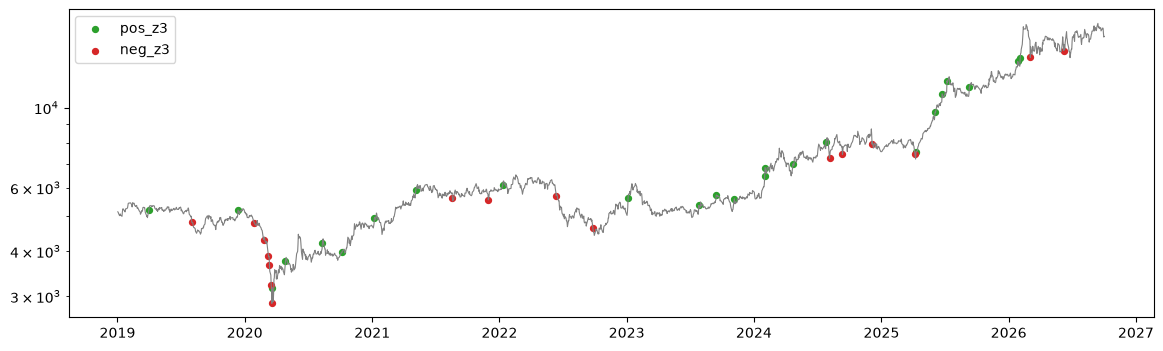

In [17]:
DEFS = [c for c in x.columns if c.startswith(("pos_z", "neg_z", "abs_z")) or c in ("pos_q95", "neg_q05", "abs_q95")]
CNT = pd.DataFrame({"definition": DEFS, "n_days": [int(x[c].sum()) for c in DEFS]}); display(CNT)
absdefs = ["abs_z2", "abs_z2_5", "abs_z3", "abs_q95"]
JAC = pd.DataFrame([[eu.jaccard(x[a], x[b]) for b in absdefs] for a in absdefs], index=absdefs, columns=absdefs); display(JAC)
TOP = x.loc[x["ret_z20"].abs().nlargest(10).index, ["date", "price", "log_ret", "ret_z20", "roll_vol_20"]]; display(TOP)
fig, ax = plt.subplots(figsize=(14, 4)); ax.plot(x["date"], x["price"], lw=.8, c="gray"); ax.set_yscale("log")
ax.scatter(x["date"][x["pos_z3"]], x["price"][x["pos_z3"]], c="tab:green", s=18, label="pos_z3")
ax.scatter(x["date"][x["neg_z3"]], x["price"][x["neg_z3"]], c="tab:red", s=18, label="neg_z3"); ax.legend(); plt.show()
N_POS3, N_NEG3, N_ABS3 = int(x["pos_z3"].sum()), int(x["neg_z3"].sum()), int(x["abs_z3"].sum())

### 07b 정의별 극단일 표 (① abs% q95 ② shift(1) robust z w60 k3 ③ percentile q01/q99)

In [18]:
XDEF, XSC = eu.extreme_definitions(x)
for nm, msk in XDEF.items():
    t = x.loc[msk, ["date", "ret_1d", "log_ret"]].assign(score=XSC[nm][msk])
    print(f"[{nm}] n_days={int(msk.sum())}"); display(t.nlargest(10, "score"))
ks = list(XDEF)
JAC3 = {f"{ks[i]}~{ks[j]}": eu.jaccard(XDEF[ks[i]], XDEF[ks[j]]) for i in range(3) for j in range(i + 1, 3)}
print("Jaccard: " + " | ".join(f"{k}={v:.3f}" for k, v in JAC3.items()))

[abs_pct_q95] n_days=96


,date,ret_1d,log_ret,score
300,2020-03-20,0.1068,0.1014,0.1068
1758,2026-03-04,-0.1034,-0.1092,0.1034
303,2020-03-25,0.0942,0.0901,0.0942
325,2020-04-27,0.0913,0.0873,0.0913
301,2020-03-23,-0.0858,-0.0897,0.0858
299,2020-03-19,-0.0852,-0.0891,0.0852
1822,2026-06-08,-0.0837,-0.0874,0.0837
1379,2024-08-05,-0.0771,-0.0802,0.0771
1600,2025-07-08,0.0728,0.0702,0.0728
1759,2026-03-05,0.0697,0.0673,0.0697


[robust_z_shift1_w60_k3] n_days=69


,date,ret_1d,log_ret,score
300,2020-03-20,0.1068,0.1014,9.2575
299,2020-03-19,-0.0852,-0.0891,7.8940
1758,2026-03-04,-0.1034,-0.1092,7.5170
303,2020-03-25,0.0942,0.0901,7.2902
301,2020-03-23,-0.0858,-0.0897,7.0051
1195,2023-11-06,0.0476,0.0465,6.2323
1600,2025-07-08,0.0728,0.0702,6.1449
1539,2025-04-07,-0.0501,-0.0514,6.0471
1614,2025-07-28,-0.0544,-0.0560,6.0409
849,2022-06-13,-0.0469,-0.0481,5.8118


[pctile_q01_q99] n_days=40


,date,ret_1d,log_ret,score
300,2020-03-20,0.1068,0.1014,0.1068
1758,2026-03-04,-0.1034,-0.1092,0.1034
303,2020-03-25,0.0942,0.0901,0.0942
325,2020-04-27,0.0913,0.0873,0.0913
301,2020-03-23,-0.0858,-0.0897,0.0858
299,2020-03-19,-0.0852,-0.0891,0.0852
1822,2026-06-08,-0.0837,-0.0874,0.0837
1379,2024-08-05,-0.0771,-0.0802,0.0771
1600,2025-07-08,0.0728,0.0702,0.0728
1759,2026-03-05,0.0697,0.0673,0.0697


Jaccard: abs_pct_q95~robust_z_shift1_w60_k3=0.460 | abs_pct_q95~pctile_q01_q99=0.417 | robust_z_shift1_w60_k3~pctile_q01_q99=0.434


In [19]:
cap("07", {"n_pos_z3": N_POS3, "n_neg_z3": N_NEG3, "n_abs_z3": N_ABS3, "n_abs_z2": int(x["abs_z2"].sum()),
           "n_abs_q95": int(x["abs_q95"].sum()), "jaccard_abs_z3_vs_abs_q95": JAC.loc["abs_z3", "abs_q95"],
           "jaccard_abs_z2_vs_abs_z3": JAC.loc["abs_z2", "abs_z3"], **{f"n_{k}": int(v.sum()) for k, v in XDEF.items()}, **{f"jac_{k}": v for k, v in JAC3.items()}, "max_abs_ret_z20": x["ret_z20"].abs().max()})

#### 07 · WHAT WE SEE
- `n_pos_z3` = 24
- `n_neg_z3` = 17
- `n_abs_z3` = 41
- `n_abs_z2` = 140
- `n_abs_q95` = 96
- `jaccard_abs_z3_vs_abs_q95` = 0.3431
- `jaccard_abs_z2_vs_abs_z3` = 0.2929
- `n_abs_pct_q95` = 96
- `n_robust_z_shift1_w60_k3` = 69
- `n_pctile_q01_q99` = 40
- `jac_abs_pct_q95~robust_z_shift1_w60_k3` = 0.4602
- `jac_abs_pct_q95~pctile_q01_q99` = 0.4167
- `jac_robust_z_shift1_w60_k3~pctile_q01_q99` = 0.4342
- `max_abs_ret_z20` = 5.325

#### WHY IT MATTERS
후보 정의마다 선택되는 날이 얼마나 겹치는지는 극단 정의가 정의 선택에 얼마나 민감한지를 보여준다 (최종 정의는 여기서 정하지 않는다).

#### WHAT WE DO NOT KNOW
- q95/q05 후보는 전체표본 분위수(look-ahead) 이므로 실시간 탐지에는 쓸 수 없다.

#### NEXT QUESTION
- 후보 정의 간 불일치가 큰 날들은 어떤 공통 특성을 갖는가?

> A/C 해석 통합 대기 (ETF_CARDS)


## 08 Benchmark / Peer Relationship

benchmark (index name): KRX 은행 (추정) | proxy ticker: 069500


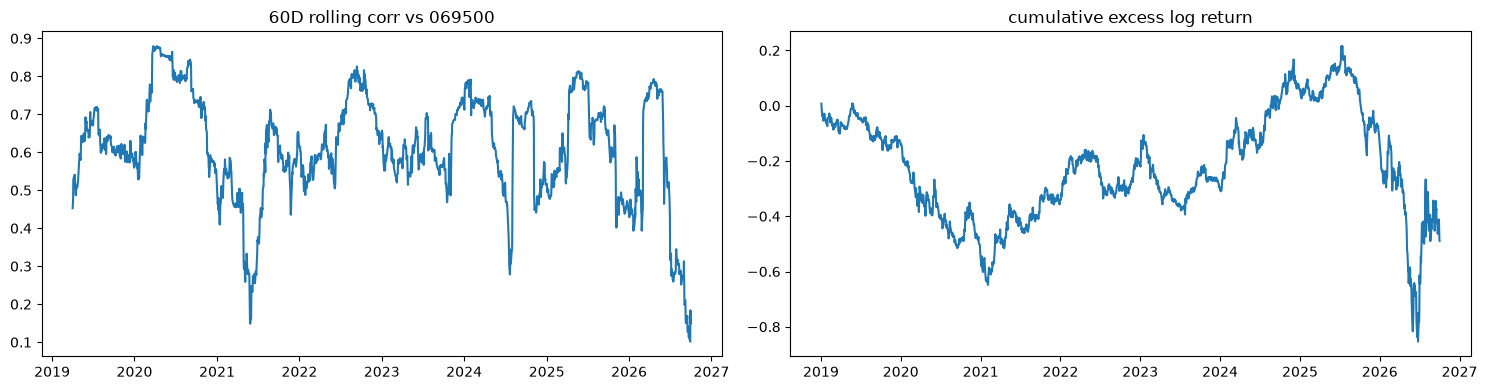

,091170,091230,091180,305540,143860,117680,161510
091170,1.0000,0.3629,0.4995,0.3529,0.3608,0.5277,0.8619
091230,0.3629,1.0000,0.5133,0.5120,0.4678,0.4826,0.4708
091180,0.4995,0.5133,1.0000,0.5013,0.3958,0.5582,0.6350
305540,0.3529,0.5120,0.5013,1.0000,0.4665,0.6191,0.4511
143860,0.3608,0.4678,0.3958,0.4665,1.0000,0.4536,0.4362
117680,0.5277,0.4826,0.5582,0.6191,0.4536,1.0000,0.6573
161510,0.8619,0.4708,0.6350,0.4511,0.4362,0.6573,1.0000


In [20]:
BETA = CORR = None; BST = {}
bm = row.get("benchmark_proxy_ticker", "")
print("benchmark (index name):", row.get("benchmark", ""), "| proxy ticker:", bm or "(none)")
if bm and bm != TICKER and eu.raw_path(bm).exists():
    b, _ = eu.load_raw(eu.raw_path(bm)); b, _ = eu.engineer_basic(b)
    m = x[["date", "log_ret"]].merge(b[["date", "log_ret"]], on="date", how="outer", suffixes=("", "_bm"), indicator=True)
    n_unm = int((m["_merge"] != "both").sum()); mm = m[m["_merge"] == "both"].dropna(subset=["log_ret", "log_ret_bm"]).sort_values("date")
    BETA = float(np.cov(mm["log_ret"], mm["log_ret_bm"])[0, 1] / mm["log_ret_bm"].var()); CORR = float(mm["log_ret"].corr(mm["log_ret_bm"]))
    rc = mm["log_ret"].rolling(60).corr(mm["log_ret_bm"])
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    ax[0].plot(mm["date"], rc); ax[0].set_title(f"60D rolling corr vs {bm}")
    ax[1].plot(mm["date"], (mm["log_ret"] - mm["log_ret_bm"]).cumsum()); ax[1].set_title("cumulative excess log return")
    plt.tight_layout(); plt.show()
    BST = {"benchmark": bm, "n_unmatched_dates": n_unm, "n_matched": len(mm), "beta": BETA, "corr": CORR, "rolling_corr60_min": rc.min()}
else:
    reason = "benchmark_proxy_ticker 미지정" if not bm else ("self" if bm == TICKER else "benchmark raw 없음")
    print("SKIP benchmark:", reason); BST = {"benchmark_skip": reason}
    if bm and bm != TICKER: LIMITATIONS.append("benchmark_missing")  # proxy 미지정(기준 자체·비주식)은 설계상 정상
pg = row.get("peer_group", "")
peers = [t for t in U.loc[(U["peer_group"] == pg) & (U["ticker"] != TICKER), "ticker"] if pg and eu.raw_path(t).exists()]
if peers:
    rets = {TICKER: x.set_index("date")["log_ret"]}
    for t in peers:
        d, _ = eu.load_raw(eu.raw_path(t)); d, _ = eu.engineer_basic(d); rets[t] = d.set_index("date")["log_ret"]
    PC = pd.DataFrame(rets).corr(); display(PC); BST["n_peers"] = len(peers); BST["peer_corr_mean"] = PC[TICKER].drop(TICKER).mean()
else:
    print("peer 없음 (peer_group=", pg, ")")

In [21]:
cap("08", BST)

#### 08 · WHAT WE SEE
- `benchmark` = 069500
- `n_unmatched_dates` = 0
- `n_matched` = 1902
- `beta` = 0.5145
- `corr` = 0.5349
- `rolling_corr60_min` = 0.1014
- `n_peers` = 6
- `peer_corr_mean` = 0.4943

#### WHY IT MATTERS
벤치마크·peer 와의 동조성은 개별 ETF 신호와 시장 공통 신호를 분리(초과수익 정규화)해야 하는지에 대한 근거가 된다.

#### WHAT WE DO NOT KNOW
- benchmark 는 universe 내 대리 ticker 이며 공식 추종지수 자체가 아닐 수 있다.

#### NEXT QUESTION
- 극단 후보를 원수익률이 아니라 benchmark 초과수익으로 정의해야 하는가?

> A/C 해석 통합 대기 (ETF_CARDS)


## 09 Multivariate Structure (diagnostic)

,pc,explained_ratio
0,PC1,0.4088
1,PC2,0.2327
2,PC3,0.1498
3,PC4,0.1007


pc,PC1,PC2,PC3,PC4
log_ret,0.0755,-0.1200,0.9777,-0.0186
abs_ret,0.4058,0.3081,0.0100,-0.5137
roll_vol_20,0.1677,0.5908,0.1395,0.6436
drawdown,-0.0233,-0.2573,0.1006,-0.3379
range_pct,0.4837,0.4081,-0.0200,-0.3159
volume_robust_z_20,0.7530,-0.5558,-0.1185,0.3279


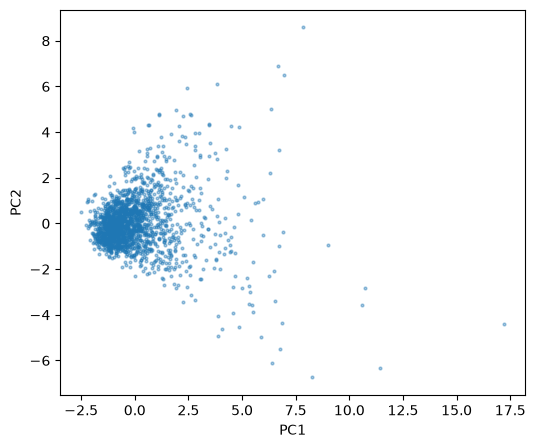

In [22]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
feats = ["log_ret", "abs_ret", "roll_vol_20", "drawdown"] + (["range_pct"] if "range_pct" in x else []) + (["volume_robust_z_20"] if HAS_VOL else [])
F = x[feats].replace([np.inf, -np.inf], np.nan).dropna()
Z = RobustScaler().fit_transform(F); pca = PCA(n_components=min(len(feats), 4), random_state=0).fit(Z)
EVR = pd.DataFrame({"pc": [f"PC{i+1}" for i in range(pca.n_components_)], "explained_ratio": pca.explained_variance_ratio_}); display(EVR)
LOAD = pd.DataFrame(pca.components_.T, index=feats, columns=EVR["pc"]); display(LOAD)
S = pca.transform(Z); plt.figure(figsize=(6, 5)); plt.scatter(S[:, 0], S[:, 1], s=4, alpha=.4); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()
PC1 = float(pca.explained_variance_ratio_[0])

In [23]:
cap("09", {"n_rows_used": len(F), "features": ", ".join(feats), "pc1_ratio": PC1, "pc2_ratio": float(pca.explained_variance_ratio_[1]),
           "pc1_top_loading": LOAD["PC1"].abs().idxmax()})

#### 09 · WHAT WE SEE
- `n_rows_used` = 1882
- `features` = log_ret, abs_ret, roll_vol_20, drawdown, range_pct, volume_robust_z_20
- `pc1_ratio` = 0.4088
- `pc2_ratio` = 0.2327
- `pc1_top_loading` = volume_robust_z_20

#### WHY IT MATTERS
여러 feature 가 소수의 축으로 요약되는지는 다변량 정규화·차원 축소가 필요한지에 대한 진단이다.

#### WHAT WE DO NOT KNOW
- PCA 는 선형·전체표본 진단이며, 축의 의미를 확정하지 않는다.

#### NEXT QUESTION
- PC1 이 주로 변동성 축인가, 방향 축인가 — 이것이 ETF 간에 일관적인가?

> A/C 해석 통합 대기 (ETF_CARDS)


## 10 Questions Discovered (SEED only — ACCEPTED/REJECTED 금지)

In [24]:
Q = []
def seed(cond, scope, stmt, ev):
    if cond: Q.append({"id": f"{TICKER}-Q{len(Q)+1:02d}", "scope": scope, "statement": stmt, "status": "SEED", "evidence": ev})
seed(K["ex_kurt"] > 5 and K["ex_kurt_trim3"] > 5, "distribution", "꼬리가 두꺼워 정규 가정 z 정규화가 부적합할 수 있다", f"ex_kurt={K['ex_kurt']:.2f}, trim3={K['ex_kurt_trim3']:.2f}")
seed(ZERO_VOL_RATIO > .01, "volume", "거래량 0 일이 많아 거래량 baseline 이 불안정할 수 있다", f"zero_vol_ratio={ZERO_VOL_RATIO:.3f}")
seed(MAX_DD < -.30, "drawdown", "깊은 낙폭 구간이 정규화 창을 지배할 수 있다", f"max_dd={MAX_DD:.3f}")
seed(abs(ACF_ABS[0]) > .2, "volatility", "변동성 군집이 강해 시간가변 baseline 이 필요할 수 있다", f"acf_absret_lag1={ACF_ABS[0]:.3f}")
seed(not HAS_VOL, "volume", "거래량 부재 — 거래량 기반 후보 정의 불가", "has_volume=False")
seed(CORR is not None and CORR > .9, "benchmark", "benchmark 와 거의 동조 — 초과수익 기준 후보 정의 검토", f"corr={CORR}")
QT = pd.DataFrame(Q, columns=["id", "scope", "statement", "status", "evidence"]); display(QT)

,id,scope,statement,status,evidence
0,091170-Q01,drawdown,깊은 낙폭 구간이 정규화 창을 지배할 수 있다,SEED,max_dd=-0.474
1,091170-Q02,volatility,변동성 군집이 강해 시간가변 baseline 이 필요할 수 있다,SEED,acf_absret_lag1=0.238


## 11 Observation → Implication → Next Question

In [25]:
SUM = pd.DataFrame([
  ("03", "ann_vol / ex_kurt / ex_kurt_trim3", f"{K['ann_vol']:.3f} / {K['ex_kurt']:.2f} / {K['ex_kurt_trim3']:.2f}", eu.NEXT_Q["03"]),
  ("04", "acf_absret_lag1", f"{ACF_ABS[0]:.3f}", eu.NEXT_Q["04"]),
  ("06", "max_dd (date)", f"{MAX_DD:.3f} ({MAX_DD_DATE})", eu.NEXT_Q["06"]),
  ("07", "n_abs_z3 / n_abs_q95", f"{N_ABS3} / {int(x['abs_q95'].sum())}", eu.NEXT_Q["07"]),
  ("08", "corr / beta vs benchmark", f"{CORR} / {BETA}", eu.NEXT_Q["08"]),
  ("09", "pc1_ratio", f"{PC1:.3f}", eu.NEXT_Q["09"]),
], columns=["section", "observation", "number", "next_question"]); display(SUM)
display(Markdown(eu.PLACEHOLDER))

,section,observation,number,next_question
0,03,ann_vol / ex_kurt / ex_kurt_trim3,0.274 / 4.31 / 3.08,꼬리 두께를 감안할 때 z-score 대신 robust/분위수 기반 정규화가 필요한가?
1,04,acf_absret_lag1,0.238,baseline 창 길이(20 vs 60)를 무엇으로 고를 것인가?
2,06,max_dd (date),-0.474 (2020-03-19),극단일 이후 며칠까지를 이벤트 창으로 볼 것인가?
3,07,n_abs_z3 / n_abs_q95,41 / 96,후보 정의 간 불일치가 큰 날들은 어떤 공통 특성을 갖는가?
4,08,corr / beta vs benchmark,0.5348775172899981 / 0.5145129536814234,극단 후보를 원수익률이 아니라 benchmark 초과수익으로 정의해야 하는가?
5,09,pc1_ratio,0.409,"PC1 이 주로 변동성 축인가, 방향 축인가 — 이것이 ETF 간에 일관적인가?"


> A/C 해석 통합 대기 (ETF_CARDS)

## 12 Profile Export

In [26]:
PROFILE = {"slot": SLOT, "ticker": TICKER, "name": row.get("name"), "asset_scope": row.get("asset_scope"), "category": row.get("category"),
  "peer_group": row.get("peer_group"), "leverage_inverse": row.get("leverage_inverse"), "start": START, "end": END, "n_obs": N,
  "ann_vol": K["ann_vol"], "mean_ret": K["mean"], "skew": K["skew"], "ex_kurt": K["ex_kurt"], "ex_kurt_trim3": K["ex_kurt_trim3"], "p01": K["p01"], "p99": K["p99"],
  "max_dd": MAX_DD, "max_dd_date": MAX_DD_DATE, "recovery_days": RECOVERY_DAYS, "zero_vol_ratio": ZERO_VOL_RATIO, "vol_of_vol": VOL_OF_VOL,
  "acf_absret_lag1": ACF_ABS[0], "acf_sqret_lag1": ACF_SQ[0], "n_pos_z3": N_POS3, "n_neg_z3": N_NEG3, "n_abs_z3": N_ABS3,
  "beta_vs_benchmark": BETA, "corr_vs_benchmark": CORR, "pca_pc1_ratio": PC1, "price_policy": PROV["price_policy"],
  "has_volume": HAS_VOL, "rows_raw": PROV["rows_raw"], "n_duplicate_dates": PROV["n_duplicate_dates"],
  "run_limitations": sorted(set(LIMITATIONS))}
out = eu.save_profile(PROFILE, ROOT / "data" / "interim" / "profiles" / f"{TICKER}.json")
print("saved", out); PROFILE

saved /home/sieg/projects-wsl/hongik_univ_26_2/SA/.worktrees/SA_ETF/b/data/interim/profiles/091170.json


{'slot': 7,
 'ticker': '091170',
 'name': 'KODEX 은행',
 'asset_scope': 'domestic_equity',
 'category': 'sector',
 'peer_group': 'KR_sector',
 'leverage_inverse': 'none',
 'start': Timestamp('2019-01-02 00:00:00'),
 'end': Timestamp('2026-10-02 00:00:00'),
 'n_obs': 1903,
 'ann_vol': np.float64(0.27377865726789796),
 'mean_ret': np.float64(0.000588704346143817),
 'skew': np.float64(-0.013271838904370137),
 'ex_kurt': np.float64(4.312827805273696),
 'ex_kurt_trim3': 3.0753566903727627,
 'p01': np.float64(-0.0451475475500032),
 'p99': np.float64(0.04959224815586462),
 'max_dd': -0.47441775169631395,
 'max_dd_date': datetime.date(2020, 3, 19),
 'recovery_days': 377,
 'zero_vol_ratio': 0.0,
 'vol_of_vol': 0.43263104931780744,
 'acf_absret_lag1': 0.2382628498135115,
 'acf_sqret_lag1': 0.3161118463409969,
 'n_pos_z3': 24,
 'n_neg_z3': 17,
 'n_abs_z3': 41,
 'beta_vs_benchmark': 0.5145129536814234,
 'corr_vs_benchmark': 0.5348775172899981,
 'pca_pc1_ratio': 0.40881025473767907,
 'price_policy': 